# Przygotowanie danych

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn import tree
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/Bank Churn Modelling.csv")

In [ ]:
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Usuń zmienne Surname oraz CustomerId.

In [ ]:
data = data.drop(columns = ["CustomerId", "Surname"])

In [ ]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Zmienne kategoryczne (np. Geography, Gender) zakoduj metodą One-Hot lub Label Encoding.

In [ ]:
le = LabelEncoder()
data['Geography'] = le.fit_transform(data['Geography'])
data['Gender'] = le.fit_transform(data['Gender'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


Podziel zbiór na treningowy i testowy w proporcji 70:30 (random_state=42).

In [ ]:
X = data.copy()
y = X.pop('Churn')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
y.value_counts(normalize=True)

,proportion
Churn,
0,0.7963
1,0.2037


<Axes: xlabel='Churn', ylabel='count'>

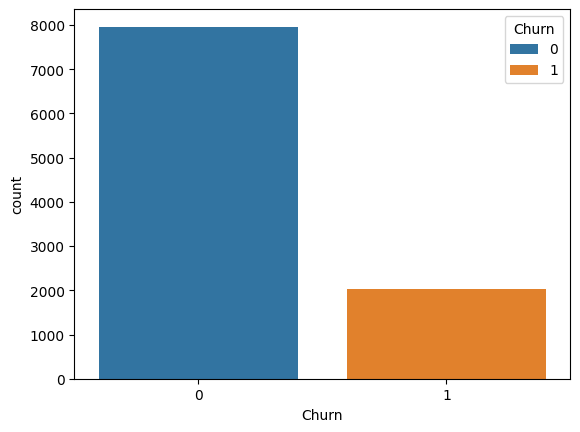

In [ ]:
sns.countplot(data=data,x='Churn', hue='Churn')

# Zadanie 1

Zbuduj dwa modele drzewa decyzyjnego (DecisionTreeClassifier):

Model A: Bez ograniczeń głębokości (max_depth=None).

In [ ]:
model_A = DecisionTreeClassifier(random_state=1)
model_A.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
pred_A = model_A.predict(X_test)
confusion_matrix(y_test, pred_A)

array([[1719,  284],
       [ 247,  250]])

In [ ]:
model_B = DecisionTreeClassifier(random_state=1, max_depth = 4)
model_B.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=1)

In [ ]:
pred_B = model_B.predict(X_test)
confusion_matrix(y_test, pred_B)

array([[1955,   48],
       [ 315,  182]])

In [ ]:
accuracy_score(y_test, pred_A)

0.7876

In [ ]:
pred_A2 = model_A.predict(X_train)
accuracy_score(y_train, pred_A2)

1.0

In [ ]:
accuracy_score(y_test, pred_B)

0.8548

In [ ]:
pred_B2 = model_B.predict(X_train)
accuracy_score(y_train, pred_B2)

0.8529333333333333

In [ ]:
accuracy_score(y_train, pred_A2) - accuracy_score(y_test, pred_A)

0.21240000000000003

Różnica w Accuracy (Train - Test) dla Modelu A wynosi: 0.21240000000000003

Który model (A czy B) wykazuje silniejsze cechy przeuczenia (overfittingu)?

Model A, ponieważ acc dla zbioru treningowego wynosi 1.

Wygeneruj grafikę drzewa dla Modelu B (skorzystaj z plot_tree)

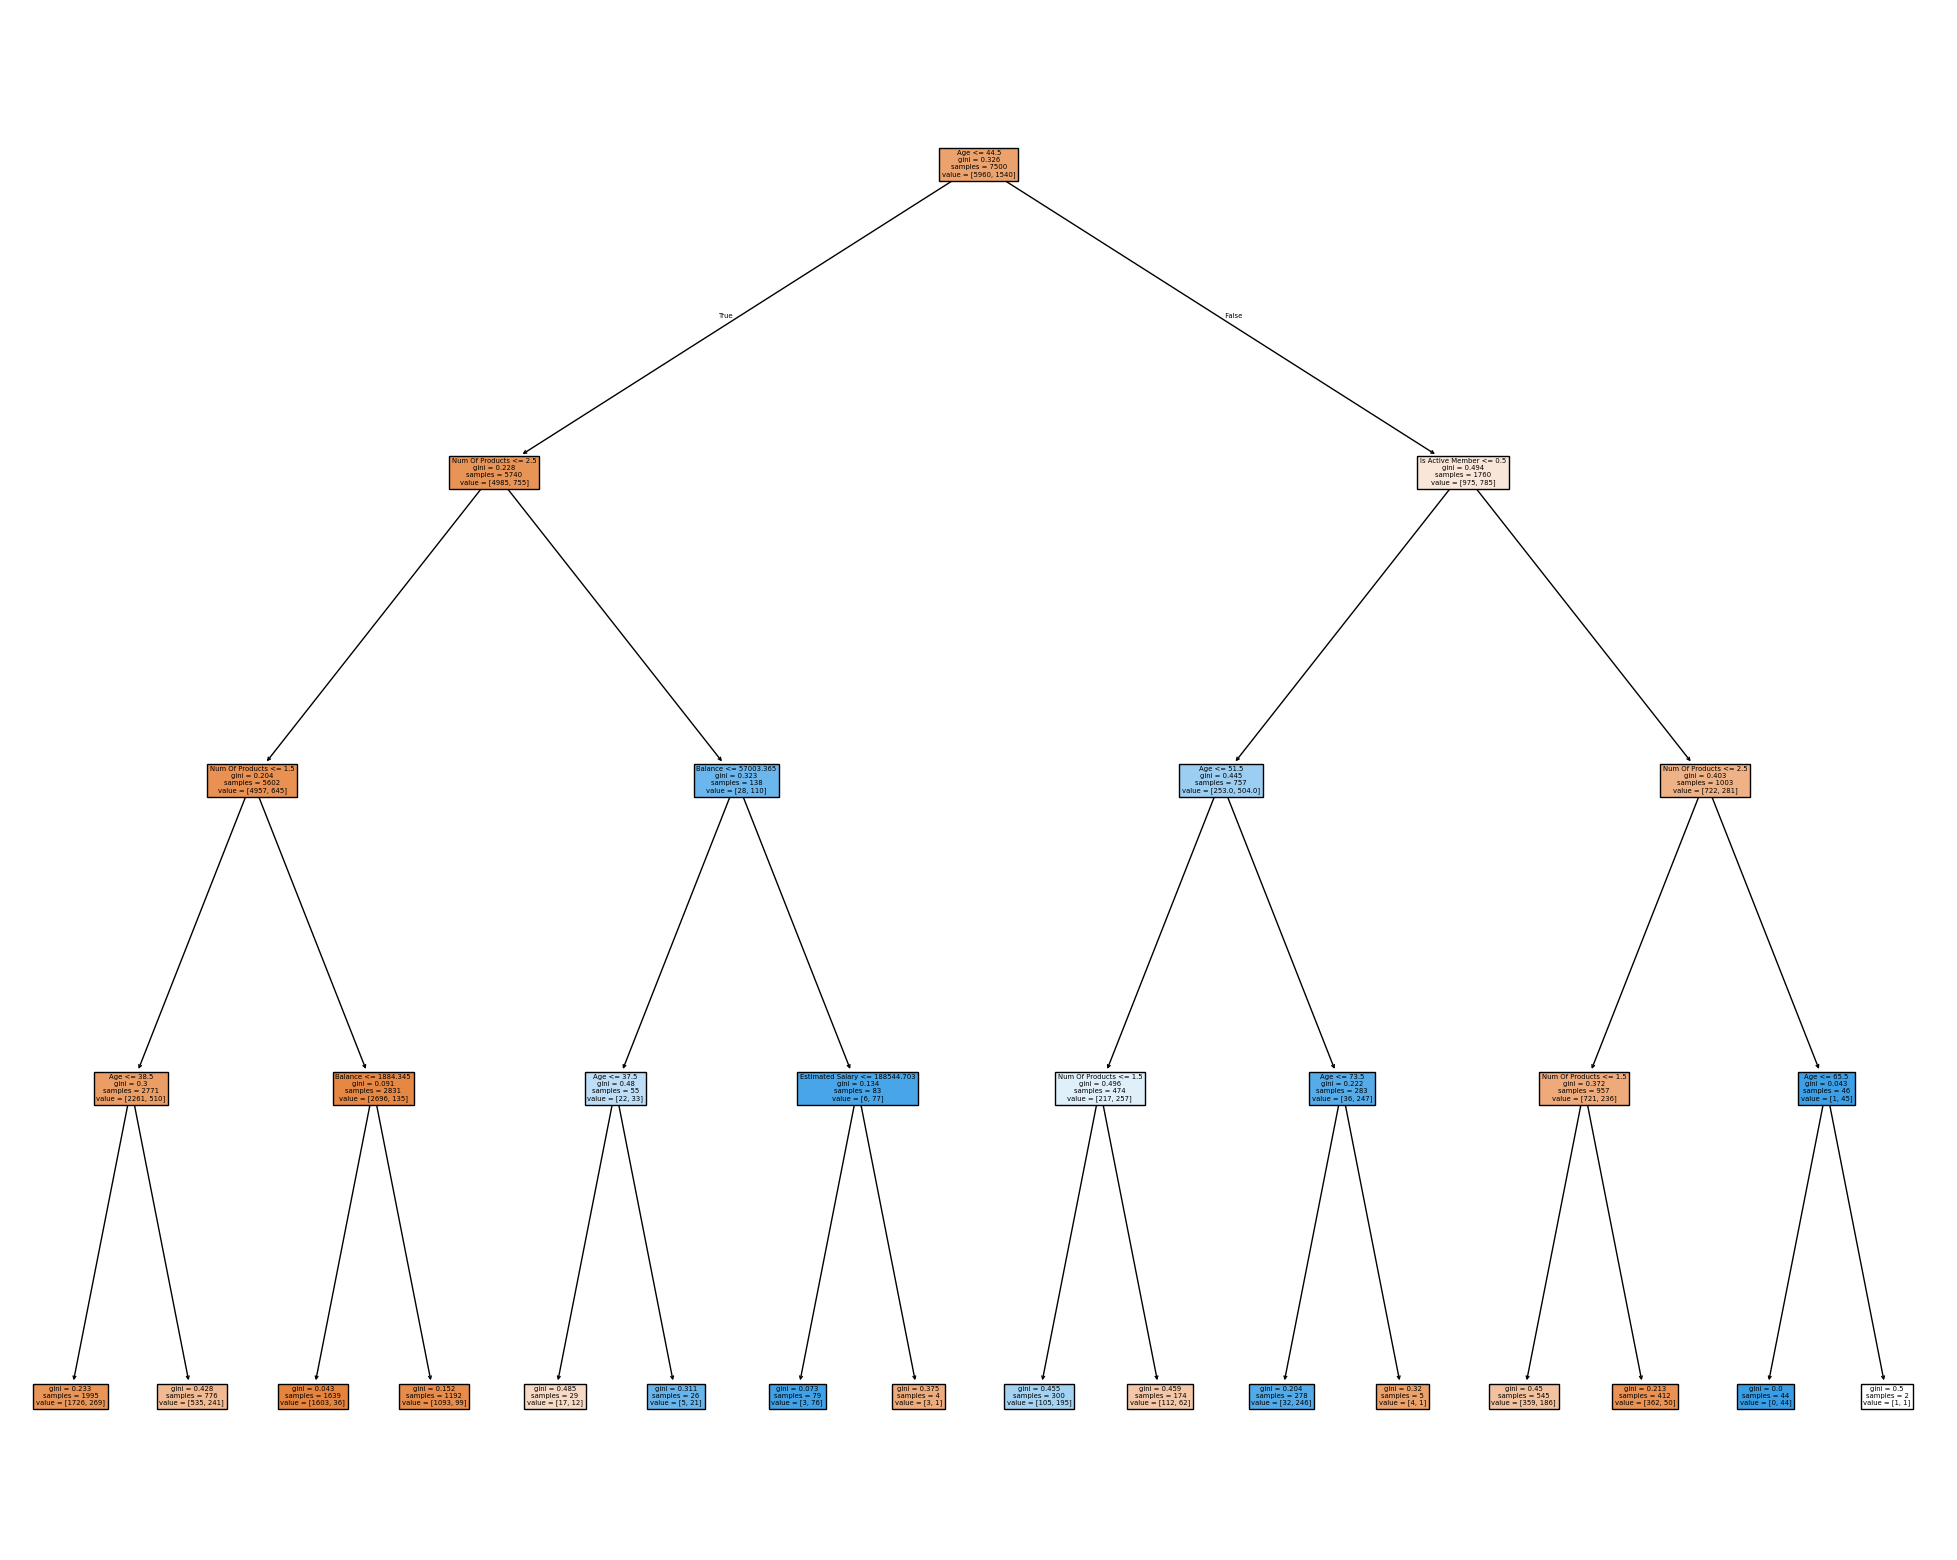

In [ ]:
features = ['CreditScore',	'Geography',	'Gender',	'Age',	'Tenure',	'Balance',	'Num Of Products',	'Has Credit Card',	'Is Active Member',	'Estimated Salary']
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(model_B,
                   feature_names=features,
                   filled=True)

In [ ]:
print(model_B.tree_.threshold[0])

44.5


Jaka zmienna znajduje się w korzeniu (root node) tego drzewa? Age

Jaka jest wartość graniczna (threshold) w korzeniu drzewa? 44,5 (age<=44,5 w korzeniu)

Wygeneruj wykres krzywej uczenia (learning curve) dla Modelu B, używając miary accuracy

In [ ]:
from sklearn.model_selection import learning_curve
#liczba próbek treningowych, dokładność na zbiorze treningowym, dokładność na zbiorze walidacyjnym

train_sizes, train_scores, test_scores =\
                learning_curve(estimator=model_B,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10), #model jest trenowany na 10 różnych rozmiarach danych (od 10% do 100%)
                               cv=10, #10-krotna walidacja krzyżowa
                               n_jobs=-1) #n_jobs=-1: Przyspiesza obliczenia, wykorzystując wszystkie dostępne rdzenie procesora do równoległego trenowania modeli.

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1) # średnia accuracy z 10 foldów
test_std = np.std(test_scores, axis=1) #zmienność między foldami
#Dla każdego rozmiaru danych liczona jest średnia dokładność oraz odchylenie standardowe (stabilność wyników)

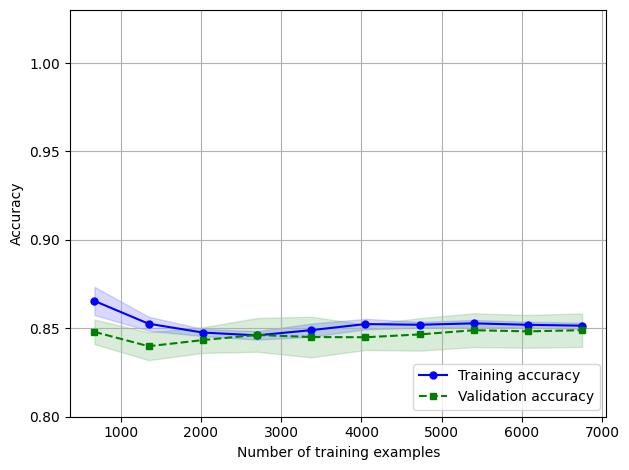

In [ ]:
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy') #Niebieska linia – dokładność na zbiorze treningowym

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')
#plt.fill_between: Tworzy półprzezroczysty obszar wokół linii. Reprezentuje on odchylenie standardowe (std) – im węższy jest ten pasek, tym bardziej stabilne i przewidywalne są wyniki modelu.

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy') #Zielona linia przerywana – dokładność na zbiorze walidacyjnym

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
plt.show()

Na podstawie wykresu oceń, czy dodanie większej liczby danych treningowych znacząco poprawiłoby wynik modelu?

Tak, można zauważyć poprawienie wyniku dla ilości danych do 4000, ale potem nie ma zauważalnej poprawy.

Dla Modelu B wygeneruj krzywą ROC i oblicz pole pod krzywą (AUC)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


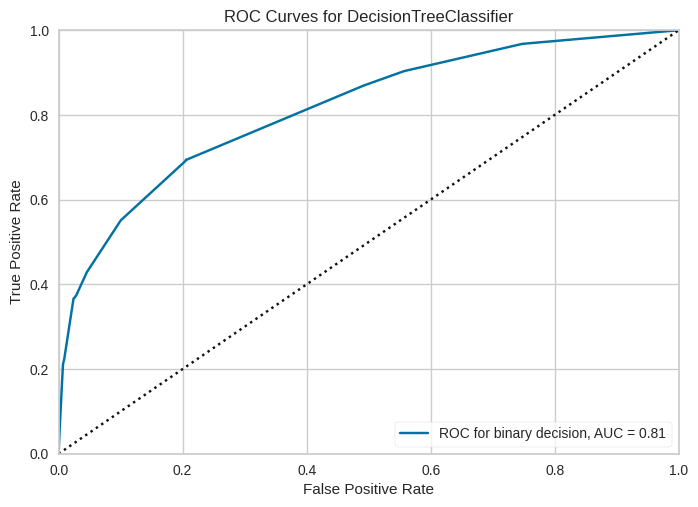

<Axes: title={'center': 'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
from yellowbrick.classifier import ROCAUC
vis = ROCAUC(model_B, binary=True)

vis.fit(X_train, y_train)        # Fit the training data to the visualizer
vis.score(X_test, y_test)        # Evaluate the model on the test data
vis.show()

Wartość AUC wynosi: 0,81

# Zadanie 2

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
params = {
    'max_depth': [3,10,None],
    'min_samples_split': [2,5],
    'n_estimators': [50,100,200]
}

from sklearn.model_selection import GridSearchCV


grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, scoring="roc_auc")


grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

In [ ]:
grid_search.best_score_

np.float64(0.8570257343327812)

In [ ]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

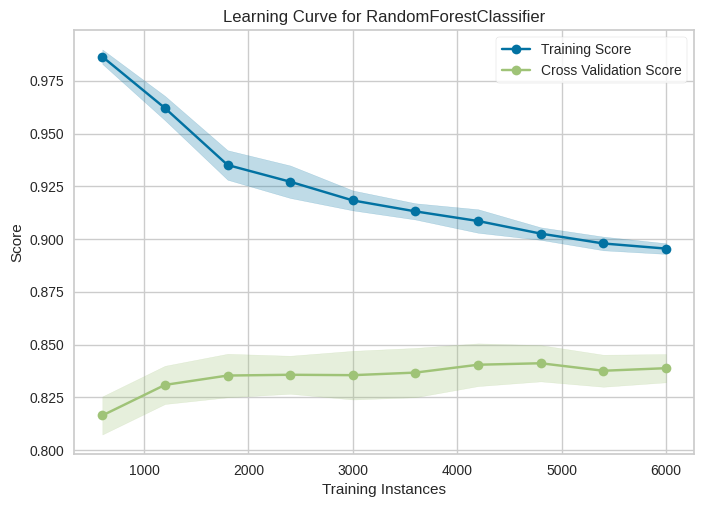

<Axes: title={'center': 'Learning Curve for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
from sklearn.model_selection import StratifiedKFold
from yellowbrick.model_selection import LearningCurve
cv = StratifiedKFold(n_splits=5)
sizes = np.linspace(0.1, 1.0, 10)
visualizer = LearningCurve(
    rf_best, cv=cv, scoring='f1_weighted', train_sizes=sizes, n_jobs=4
)

visualizer.fit(X_train, y_train)
visualizer.show()

In [ ]:
print(f"Najlepszy wynik (ROC AUC): {grid_search.best_score_:.4f}")

Najlepszy wynik (ROC AUC): 0.8570


Najlepsze parametry to: max_depth=10, n_estimators=200, min_samples_split=2

Najlepszy wynik średni (mean score) z walidacji krzyżowej wynosi: 0.8570

Dla najlepszego modelu z punktu wyżej, pobierz ważność cech (feature_importances_)

In [ ]:
rf_best_importances = rf_best.feature_importances_
rf_best_importances

array([0.0859162 , 0.03873308, 0.01997217, 0.31489403, 0.04473079,
       0.10222421, 0.22980721, 0.01111817, 0.06509746, 0.08750668])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


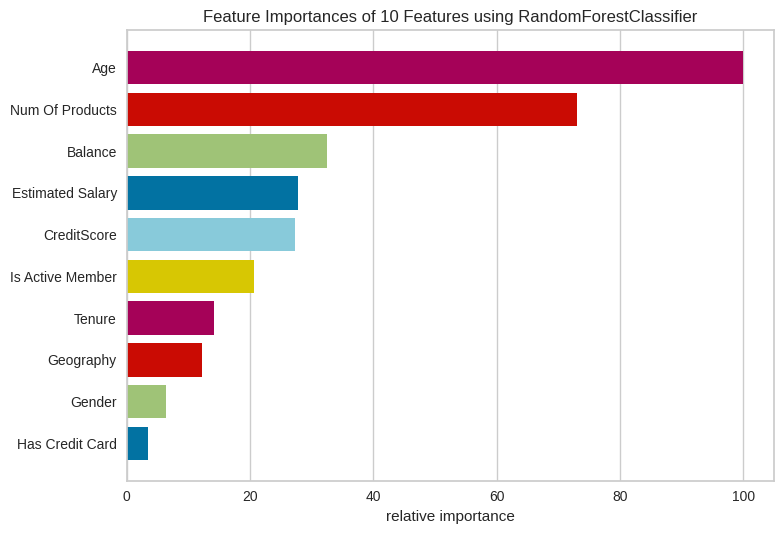

<Axes: title={'center': 'Feature Importances of 10 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [ ]:
from yellowbrick.model_selection import FeatureImportances
viz = FeatureImportances(rf_best)
viz.fit(X, y)
viz.show()

Trzy najważniejsze cechy (w kolejności malejącej) to:

1. Age
2. Num Of Products
3. Balance

Stwórz wykres krzywej walidacyjnej dla parametru n_estimators w zakresie od 10 do 200 (co 10).

In [ ]:
n_estimators = range(10, 200, 10)

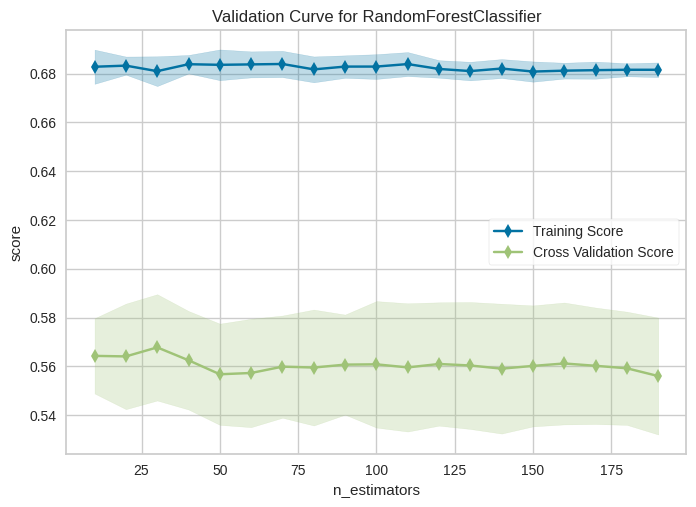

<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>

In [ ]:
from yellowbrick.model_selection import ValidationCurve
viz = ValidationCurve(
    rf_best,
    param_name="n_estimators",
    param_range=n_estimators,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

viz.fit(X, y)
viz.show()

Przy jakiej liczbie drzew wynik na zbiorze walidacyjnym przestaje znacząco rosnąć (ustabilizowanie)? około 30

# Zadanie 3

### Zbuduj model AdaBoostClassifier oraz GradientBoostingClassifier na domyślnych parametrach.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42))
abc.fit(X_train,y_train)
y_abc=abc.predict(X_test)

In [ ]:
print(classification_report(y_test,y_abc))
print("Accuracy ada= : ",accuracy_score(y_test,y_abc))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      2003
           1       0.48      0.49      0.49       497

    accuracy                           0.79      2500
   macro avg       0.68      0.68      0.68      2500
weighted avg       0.79      0.79      0.79      2500

Accuracy ada= :  0.792


### Wygeneruj wykres Precision-Recall Curve dla obu modeli na jednym rysunku.

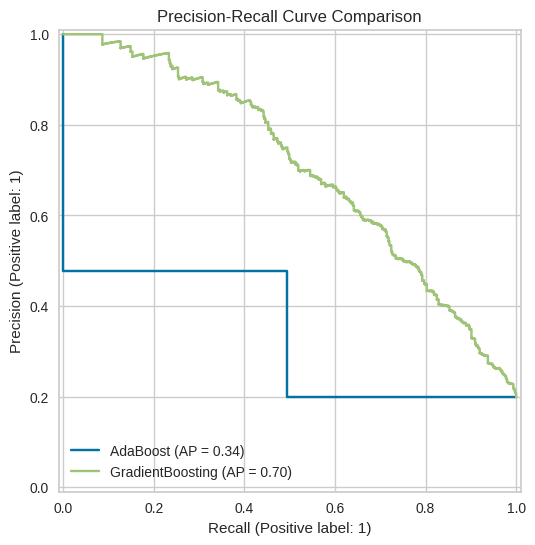

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# Krzywa dla AdaBoost
PrecisionRecallDisplay.from_estimator(abc, X_test, y_test, ax=ax, name='AdaBoost')

# Krzywa dla GradientBoosting
# Zakładam, że Twój model GradientBoosting nazywa się 'gbc'
PrecisionRecallDisplay.from_estimator(gbc, X_test, y_test, ax=ax, name='GradientBoosting')

plt.title("Precision-Recall Curve Comparison")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


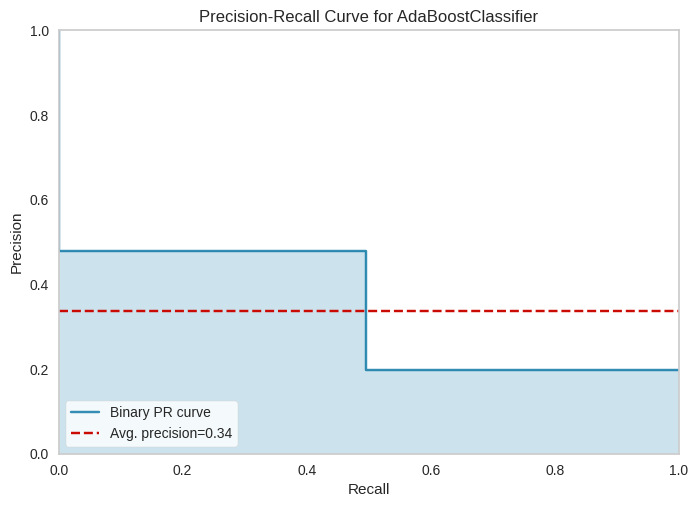

<Axes: title={'center': 'Precision-Recall Curve for AdaBoostClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
from yellowbrick.classifier import PrecisionRecallCurve
viz = PrecisionRecallCurve(abc)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
y_gbc=gbc.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


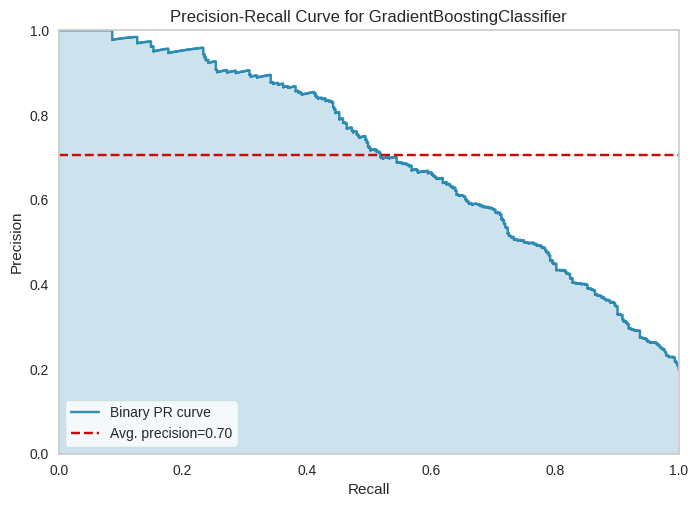

<Axes: title={'center': 'Precision-Recall Curve for GradientBoostingClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
viz = PrecisionRecallCurve(gbc)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

### Dla modelu Gradient Boosting oblicz wartość F1-score na zbiorze testowym

In [ ]:
gbc.score(X_test, y_test)

0.868

Wartość F1-score dla Gradient Boosting: ..........

### Dla modelu Gradient Boosting wygeneruj kolorową macierz pomyłek.

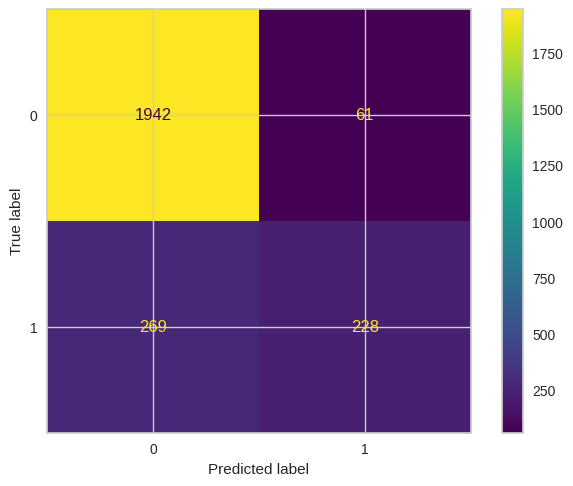

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, gbc.predict(X_test), labels=gbc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gbc.classes_)
disp.plot()
plt.show()

Dla klasy pozytywnej (klient odszedł = 1) zapisz wartości:

TP (True Positive): 228

FN (False Negative): 269

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

y_pred_gbc = gbc.predict(X_test)

# Obliczenie F1
f1 = f1_score(y_test, y_pred_gbc)
print(f"Wartość F1-score: {f1:.4f}")

# Wypisanie dokładnych wartości macierzy
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gbc).ravel()
print(f"TP (True Positive): {tp}")
print(f"TN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")

Wartość F1-score: 0.5802
TP (True Positive): 228
TN (True Negative): 1942
FP (False Positive): 61
FN (False Negative): 269


### Korzystając z modelu Gradient Boosting, oceń czy klient o poniższych parametrach odejdzie z banku (Exited=1) czy zostanie (Exited=0).:

Parametry: CreditScore=600, Geography='France', Gender='Female', Age=40, Tenure=3, Balance=60000, NumOfProducts=2, HasCrCard=1, IsActiveMember=1, EstimatedSalary=50000

In [ ]:
gbc.predict(pd.DataFrame({'CreditScore':[600],'Geography' :[0],	'Gender':[0],'Age':[40],	'Tenure':[3],	'Balance':[6000],	'Num Of Products':[2],'Has Credit Card':[1],	'Is Active Member':[1],	'Estimated Salary':[50000]}))

array([0])

In [ ]:
gbc.predict_proba(pd.DataFrame({'CreditScore':[600],'Geography' :[0],	'Gender':[0],'Age':[40],	'Tenure':[3],	'Balance':[6000],	'Num Of Products':[2],'Has Credit Card':[1],	'Is Active Member':[1],	'Estimated Salary':[50000]}))

array([[0.93002804, 0.06997196]])

Odpowiedź (Tak/Nie): NIE

Prawdopodobieństwo odejścia (predict_proba): 0.93002804